# BÀI TẬP LỚN MÔN XỬ LÝ TÍN HIỆU SỐ

**Đề số 30 — Pha mang nhiều thông tin: swap phase trên Lenna**

| Thông tin | Nội dung |
|-----------|----------|
| Họ và tên | Nguyễn Hoàng Minh Thông |
| MSSV | K25DTCN128 |
| Lớp | D25TXCN04-K |
| Giảng viên | Hồ Nhựt Minh |

---

### Mô tả bài toán

Thực hiện hoán đổi phổ pha (swap phase) giữa ảnh Lenna và ảnh Camera để chứng minh rằng **pha mang nhiều thông tin cấu trúc hơn biên độ** trong biểu diễn Fourier của ảnh số.

### Các bước thực hiện

1. Đọc ảnh A (Lenna) và tạo ảnh B dùng `skimage.data.camera()`.
2. Tính biến đổi Fourier 2D (FFT2) cho cả hai ảnh.
3. Tách phổ biên độ `|F|` và phổ pha `angle(F)` của mỗi ảnh.
4. Tạo ảnh tổng hợp: ghép biên độ của ảnh này với pha của ảnh kia.
5. Thực hiện nghịch biến đổi Fourier 2D (IFFT2) để khôi phục ảnh.
6. Trực quan hoá 4 ảnh và phổ của hai ảnh đầu vào.
7. Bàn luận kết quả.

In [7]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data, transform

### Bước 1: Đọc ảnh A (Lenna) và tạo ảnh B (Camera)

In [8]:
# Đường dẫn đến ảnh Lenna trong thư mục bài giảng
duong_dan_lenna = r'D:/HocTap_PTIT/XuLyTinHieuSo/BT_CuoiKy/FourierTransform_course-main/FourierTransform_course-main/Fourier_apps/Lenna.png'

# Đọc ảnh Lenna và chuyển về dạng mức xám (grayscale)
anh_lenna = Image.open(duong_dan_lenna).convert('L')
A = np.array(anh_lenna, dtype=float)
h, w = A.shape

# Tạo ảnh B từ bộ dữ liệu chuẩn của scikit-image
# skimage.data.camera() là ảnh chân dung người chụp ảnh, kích thước 512x512
anh_camera = data.camera().astype(float)
if anh_camera.shape != (h, w):
    anh_camera = transform.resize(anh_camera, (h, w), anti_aliasing=True)
    anh_camera = (anh_camera * 255)
B = anh_camera

print(f'Ảnh A (Lenna)  kích thước: {A.shape}')
print(f'Ảnh B (Camera) kích thước: {B.shape}')

Ảnh A (Lenna)  kích thước: (512, 512)
Ảnh B (Camera) kích thước: (512, 512)


### Bước 2 & 3: Tính FFT2D và tách biên độ, pha

In [9]:
# Tính biến đổi Fourier 2 chiều cho cả hai ảnh
F_A = np.fft.fft2(A)
F_B = np.fft.fft2(B)

# Tách phần biên độ (magnitude) và phần pha (phase) của mỗi ảnh
mag_A   = np.abs(F_A)       # biên độ ảnh A
pha_A   = np.angle(F_A)     # pha ảnh A

mag_B   = np.abs(F_B)       # biên độ ảnh B
pha_B   = np.angle(F_B)     # pha ảnh B

print('Tách biên độ và pha xong.')

Tách biên độ và pha xong.


### Bước 4 & 5: Hoán đổi pha và IFFT2D để khôi phục ảnh

In [10]:
# Swap 1: ghép biên độ A với pha B — theo lý thuyết kết quả sẽ giống ảnh B
Z1    = mag_A * np.exp(1j * pha_B)
swap1 = np.real(np.fft.ifft2(Z1))

# Swap 2: ghép biên độ B với pha A — theo lý thuyết kết quả sẽ giống ảnh A
Z2    = mag_B * np.exp(1j * pha_A)
swap2 = np.real(np.fft.ifft2(Z2))

print('Khôi phục ảnh miền không gian xong.')

Khôi phục ảnh miền không gian xong.


### Bước 6: Vẽ 4 ảnh kết quả

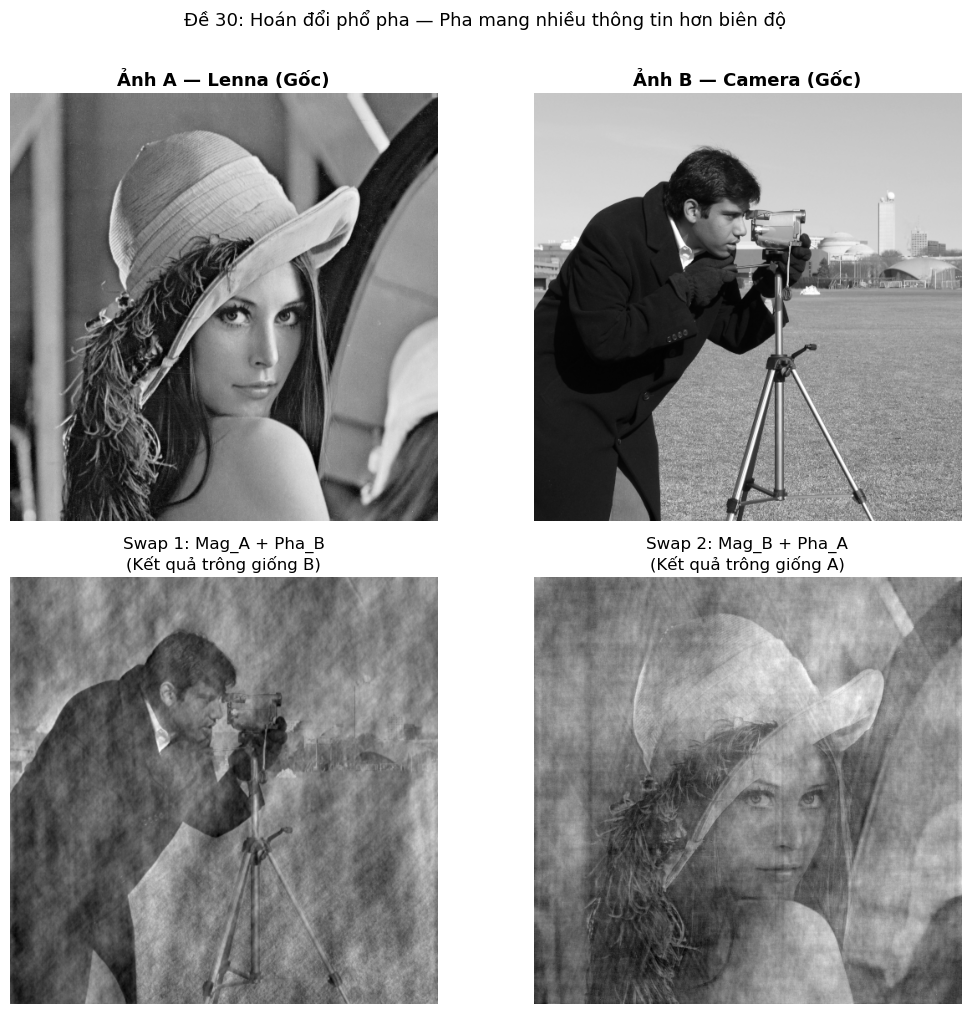

In [11]:
# Vẽ 4 ảnh so sánh: gốc và sau khi hoán đổi pha
fig, axes = plt.subplots(2, 2, figsize=(11, 10))

axes[0, 0].imshow(A, cmap='gray')
axes[0, 0].set_title('Ảnh A — Lenna (Gốc)', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(B, cmap='gray')
axes[0, 1].set_title('Ảnh B — Camera (Gốc)', fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

axes[1, 0].imshow(swap1, cmap='gray')
axes[1, 0].set_title('Swap 1: Mag_A + Pha_B\n(Kết quả trông giống B)', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(swap2, cmap='gray')
axes[1, 1].set_title('Swap 2: Mag_B + Pha_A\n(Kết quả trông giống A)', fontsize=12)
axes[1, 1].axis('off')

plt.suptitle('Đề 30: Hoán đổi phổ pha — Pha mang nhiều thông tin hơn biên độ',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('result_swap_phase.png', dpi=150, bbox_inches='tight')
plt.show()

### Khảo sát thêm: So sánh phổ biên độ và phổ pha của hai ảnh

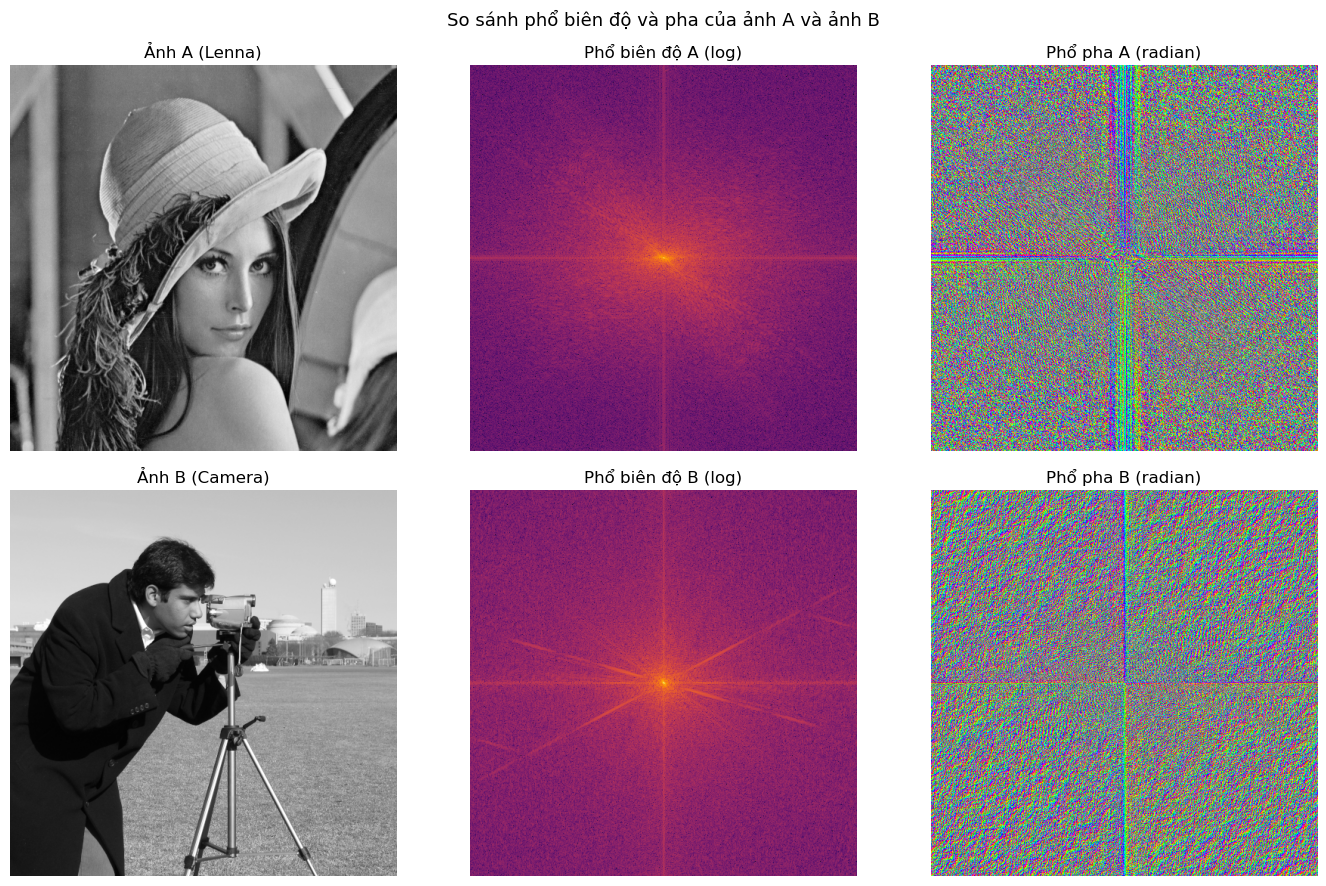

In [12]:
# Dịch chuyển tần số thấp về trung tâm để dễ nhìn hơn
F_A_shift = np.fft.fftshift(F_A)
F_B_shift = np.fft.fftshift(F_B)

# Dùng thang log để nén dải động của biên độ
log_mag_A = np.log(np.abs(F_A_shift) + 1)
log_mag_B = np.log(np.abs(F_B_shift) + 1)

fig2, axes2 = plt.subplots(2, 3, figsize=(14, 9))

axes2[0, 0].imshow(A, cmap='gray')
axes2[0, 0].set_title('Ảnh A (Lenna)', fontsize=12)
axes2[0, 0].axis('off')

axes2[0, 1].imshow(log_mag_A, cmap='inferno')
axes2[0, 1].set_title('Phổ biên độ A (log)', fontsize=12)
axes2[0, 1].axis('off')

axes2[0, 2].imshow(np.angle(F_A_shift), cmap='hsv')
axes2[0, 2].set_title('Phổ pha A (radian)', fontsize=12)
axes2[0, 2].axis('off')

axes2[1, 0].imshow(B, cmap='gray')
axes2[1, 0].set_title('Ảnh B (Camera)', fontsize=12)
axes2[1, 0].axis('off')

axes2[1, 1].imshow(log_mag_B, cmap='inferno')
axes2[1, 1].set_title('Phổ biên độ B (log)', fontsize=12)
axes2[1, 1].axis('off')

axes2[1, 2].imshow(np.angle(F_B_shift), cmap='hsv')
axes2[1, 2].set_title('Phổ pha B (radian)', fontsize=12)
axes2[1, 2].axis('off')

plt.suptitle('So sánh phổ biên độ và pha của ảnh A và ảnh B', fontsize=13)
plt.tight_layout()
plt.savefig('spectra_comparison.png', dpi=150, bbox_inches='tight')
plt.show()